In [42]:
# ── CELDA 1: Imports ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

In [43]:
# ── CELDA 2: Carga de datos ───────────────────────────────────────────────────
"""
Estrategia de features para clustering:
  Una fila por producto (referencia), columnas = estadísticos del precio
  a lo largo de los 154 días del histórico.

  No usamos precio de cada día como feature (154 columnas) porque:
  - Alta dimensionalidad → maldición de la dimensionalidad
  - K-Means con distancia euclidiana en 154 dims es poco fiable

  En su lugar usamos estadísticos descriptivos de la serie temporal:
  - precio_medio     : nivel de precio del producto
  - precio_std       : volatilidad del precio
  - precio_min/max   : rango absoluto
  - n_cambios        : número de veces que cambió de precio
  - variacion_media  : magnitud media de los cambios
  - dias_estable     : proporción de días sin cambio (estabilidad)
"""

IMG_DIR = Path("../docs/img/clustering")
IMG_DIR.mkdir(parents=True, exist_ok=True)
PARTITIONED_DIR = Path("../data/processed")

cols = ["referencia", "fecha", "precio_actual", "titulo",
        "categoria", "subcategoria", "marca_propia", "es_marca_propia"]

df = pd.read_parquet(PARTITIONED_DIR, columns=cols)
df["fecha"] = pd.to_datetime(df["fecha"].astype(str))
df = df.sort_values(["referencia", "fecha"]).reset_index(drop=True)

# Variación de precio día a día
df["precio_anterior"] = df.groupby("referencia")["precio_actual"].shift(1)
df["cambio"] = (df["precio_actual"] != df["precio_anterior"]) & df["precio_anterior"].notna()
df["variacion_abs"] = (df["precio_actual"] - df["precio_anterior"]).abs()

print(f"Datos: {len(df):,} filas | {df['referencia'].nunique():,} productos")

Datos: 763,435 filas | 5,101 productos


In [44]:
# ── CELDA 3: Feature engineering por producto ─────────────────────────────────
features_por_producto = df.groupby("referencia").agg(
    precio_medio     = ("precio_actual", "mean"),
    precio_std       = ("precio_actual", "std"),
    precio_min       = ("precio_actual", "min"),
    precio_max       = ("precio_actual", "max"),
    n_dias           = ("precio_actual", "count"),
    n_cambios        = ("cambio", "sum"),
    variacion_media  = ("variacion_abs", "mean"),
).reset_index()

# Features derivadas
features_por_producto["rango_precio"]   = (
    features_por_producto["precio_max"] - features_por_producto["precio_min"]
)
features_por_producto["cv_precio"] = (
    features_por_producto["precio_std"] / features_por_producto["precio_medio"]
).replace([np.inf, -np.inf], np.nan).fillna(0)
features_por_producto["prop_estable"]   = (           # proporción de días estable
    1 - features_por_producto["n_cambios"] / features_por_producto["n_dias"]
)
features_por_producto["variacion_media"] = (
    features_por_producto["variacion_media"].fillna(0)
)

# Añadir metadatos para interpretar los clusters
meta = df.groupby("referencia").agg(
    titulo       = ("titulo", "first"),
    categoria    = ("categoria", "first"),
    subcategoria = ("subcategoria", "first"),
    marca_propia = ("marca_propia", "first"),
    es_marca_propia = ("es_marca_propia", "first"),
).reset_index()

df_features = features_por_producto.merge(meta, on="referencia")
df_features["precio_std"] = df_features["precio_std"].fillna(0)

# FILTRADO DE OUTLIERS: Eliminamos el 1% de productos más caros (percentil 99)
limite_outliers = df_features["precio_medio"].quantile(0.99)
df_features_clean = df_features[df_features["precio_medio"] < limite_outliers].copy()

print(f"Features calculadas: {len(df_features):,} productos")
print(f"Outliers eliminados (Percentil 99 de precio medio >= {limite_outliers:.2f}€): {len(df_features) - len(df_features_clean)} productos")
print(f"Productos para clustering: {len(df_features_clean):,}")
print(df_features_clean[["precio_medio", "precio_std", "n_cambios",
                        "cv_precio", "prop_estable"]].describe())

Features calculadas: 5,101 productos
Outliers eliminados (Percentil 99 de precio medio >= 19.04€): 52 productos
Productos para clustering: 5,049
       precio_medio   precio_std    n_cambios    cv_precio  prop_estable
count   5049.000000  5049.000000  5049.000000  5049.000000   5049.000000
mean       3.233339     0.051694     1.417310     0.014173      0.990016
std        2.733143     0.162257     7.912704     0.030207      0.052046
min        0.164878     0.000000     0.000000     0.000000      0.254438
25%        1.500000     0.000000     0.000000     0.000000      0.994318
50%        2.340000     0.000000     0.000000     0.000000      1.000000
75%        3.933125     0.040028     1.000000     0.017153      1.000000
max       18.620000     3.397856   129.000000     0.387687      1.000000


In [45]:
# ── CELDA 4: Preparación para K-Means ────────────────────────────────────────
FEATURE_COLS = [
    "precio_medio",
    "precio_std",
    "rango_precio",
    "n_cambios",
    "cv_precio",
    "prop_estable",
    "variacion_media",
]

# Copiamos el DataFrame limpio para aplicar transformaciones sin alterar los datos descriptivos
df_transformed = df_features_clean.copy()

# Transformación logarítmica para normalizar la asimetría de variables monetarias/volátiles
cols_logaritmicas = ["precio_medio", "precio_std", "rango_precio", "variacion_media"]
for col in cols_logaritmicas:
    df_transformed[col] = np.log1p(df_transformed[col])

X = df_transformed[FEATURE_COLS].values

# Escalar — K-Means es sensible a la escala
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Matrix X: {X_scaled.shape}")
print("Features preparadas — Outliers removidos y normalización logarítmica completada.")

Matrix X: (5049, 7)
Features preparadas — Outliers removidos y normalización logarítmica completada.


  K=2 | Inercia=22592.6 | Silhouette=0.773
  K=3 | Inercia=16065.3 | Silhouette=0.707
  K=4 | Inercia=13296.5 | Silhouette=0.406
  K=5 | Inercia=10717.1 | Silhouette=0.441
  K=6 | Inercia=8375.4 | Silhouette=0.454
  K=7 | Inercia=7212.9 | Silhouette=0.456
  K=8 | Inercia=6307.9 | Silhouette=0.466
  K=9 | Inercia=5710.2 | Silhouette=0.409
  K=10 | Inercia=5350.6 | Silhouette=0.454


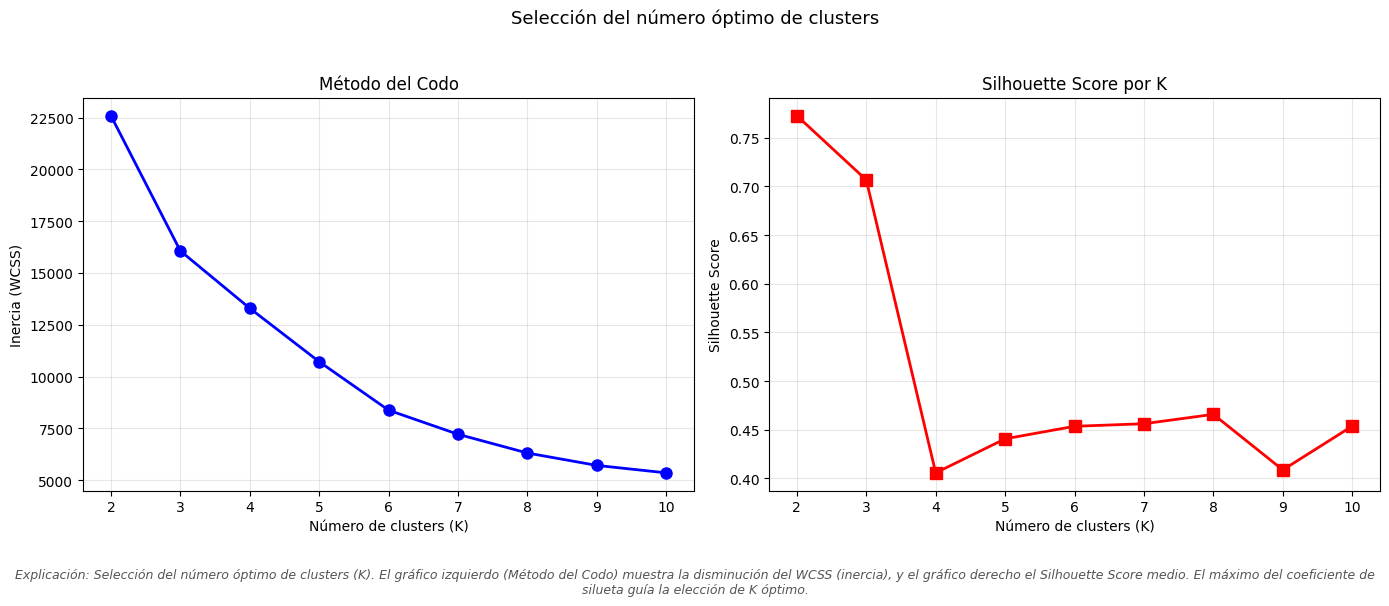


✅ K óptimo según Silhouette: 2


In [46]:
# ── CELDA 5: Método del codo para elegir K ────────────────────────────────────
"""
El método del codo calcula la inercia (suma de distancias al centroide)
para distintos valores de K. El "codo" — donde la curva deja de caer
abruptamente — indica el K óptimo.

Complementamos con el Silhouette Score: mide qué tan bien separados
están los clusters (1=perfecto, 0=solapados, -1=mal asignados).
Elegimos el K que maximiza el Silhouette Score.
"""
inercias    = []
silhouettes = []
K_range     = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    print(f"  K={k} | Inercia={km.inertia_:.1f} | Silhouette={silhouettes[-1]:.3f}")

# Gráfica del codo + Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(K_range, inercias, "bo-", linewidth=2, markersize=8)
axes[0].set_xlabel("Número de clusters (K)")
axes[0].set_ylabel("Inercia (WCSS)")
axes[0].set_title("Método del Codo")
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouettes, "rs-", linewidth=2, markersize=8)
axes[1].set_xlabel("Número de clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score por K")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Selección del número óptimo de clusters", fontsize=13)
caption = "Explicación: Selección del número óptimo de clusters (K). El gráfico izquierdo (Método del Codo) muestra la disminución del WCSS (inercia), y el gráfico derecho el Silhouette Score medio. El máximo del coeficiente de silueta guía la elección de K óptimo."
plt.figtext(0.5, 0.01, caption, wrap=True, horizontalalignment='center', fontsize=9, style='italic', color='#555555')
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.savefig(IMG_DIR / "codo_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()

K_OPTIMO = K_range[silhouettes.index(max(silhouettes))]
print(f"\n✅ K óptimo según Silhouette: {K_OPTIMO}")

In [47]:
# ── CELDA 6: Entrenamiento final con K óptimo ─────────────────────────────────
K_FINAL = 5   # Forzado a 5 clusters por criterios de valor de negocio

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)

# Asignamos los clusters sobre el dataset limpio (df_features_clean)
df_features_clean["cluster"] = km_final.fit_predict(X_scaled)

# Para no romper las celdas posteriores que puedan llamar a df_features, reasignamos la variable
df_features = df_features_clean.copy()

print(f"Clustering final con K={K_FINAL} (Datos Limpios y Transformados)")
print("\nDistribución de productos por cluster:")
print(df_features["cluster"].value_counts().sort_index())

Clustering final con K=5 (Datos Limpios y Transformados)

Distribución de productos por cluster:
cluster
0    1467
1     120
2    2942
3      30
4     490
Name: count, dtype: int64


In [48]:
# ── CELDA 7: Interpretación de clusters ──────────────────────────────────────
"""
Esta celda es la más importante para la memoria:
interpreta qué significa cada cluster en términos de negocio.
"""
resumen_clusters = df_features.groupby("cluster")[FEATURE_COLS].mean().round(3)
resumen_clusters["n_productos"] = df_features.groupby("cluster").size()
resumen_clusters["pct_marca_propia"] = (
    df_features.groupby("cluster")["es_marca_propia"].mean() * 100
).round(1)

print("Perfil medio por cluster:")
print(resumen_clusters.to_string())

# Top categorías por cluster
print("\nTop 3 categorías por cluster:")
for c in range(K_FINAL):
    top = (df_features[df_features["cluster"] == c]["categoria"]
           .value_counts().head(3))
    print(f"\n  Cluster {c}:")
    for cat, n in top.items():
        print(f"    {cat}: {n} productos")

Perfil medio por cluster:
         precio_medio  precio_std  rango_precio  n_cambios  cv_precio  prop_estable  variacion_media  n_productos  pct_marca_propia
cluster                                                                                                                            
0               5.616       0.016         0.045      0.271      0.003         0.998            0.000         1467              58.6
1               9.030       0.812         2.084      5.383      0.102         0.959            0.052          120              10.8
2               1.723       0.010         0.027      0.351      0.006         0.998            0.000         2942              77.4
3               3.772       0.576         2.304     89.100      0.137         0.418            0.125           30               0.0
4               3.714       0.189         0.515      4.912      0.064         0.962            0.009          490              26.7

Top 3 categorías por cluster:

  Cluster 0:
    c

Varianza explicada: PC1=58.4%, PC2=20.4%, Total=78.8%


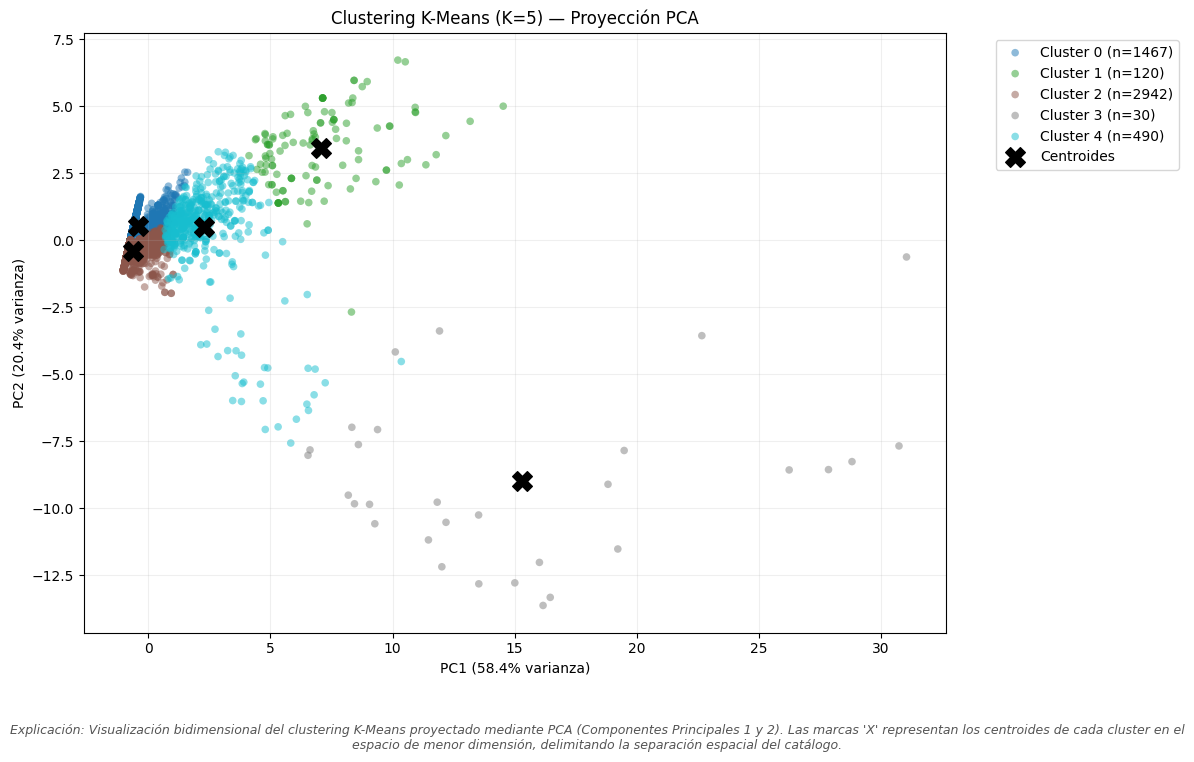

In [49]:
# ── CELDA 8: Visualización PCA 2D ────────────────────────────────────────────
"""
PCA reduce las 7 features a 2 dimensiones para visualizar los clusters.
No es perfecto (pierde información) pero permite ver la separación.
La varianza explicada indica cuánta información conservamos.
"""
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

varianza = pca.explained_variance_ratio_
print(f"Varianza explicada: PC1={varianza[0]:.1%}, PC2={varianza[1]:.1%}, "
      f"Total={sum(varianza):.1%}")

fig, ax = plt.subplots(figsize=(12, 8))
colores = cm.tab10(np.linspace(0, 1, K_FINAL))

for c in range(K_FINAL):
    mask = df_features["cluster"] == c
    n    = mask.sum()
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=[colores[c]], label=f"Cluster {c} (n={n})",
        alpha=0.5, s=30, edgecolors="none"
    )

# Centroides en espacio PCA
centroides_pca = pca.transform(km_final.cluster_centers_)
ax.scatter(centroides_pca[:, 0], centroides_pca[:, 1],
           c="black", marker="X", s=200, zorder=5, label="Centroides")

ax.set_xlabel(f"PC1 ({varianza[0]:.1%} varianza)")
ax.set_ylabel(f"PC2 ({varianza[1]:.1%} varianza)")
ax.set_title(f"Clustering K-Means (K={K_FINAL}) — Proyección PCA")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(True, alpha=0.2)

caption = "Explicación: Visualización bidimensional del clustering K-Means proyectado mediante PCA (Componentes Principales 1 y 2). Las marcas 'X' representan los centroides de cada cluster en el espacio de menor dimensión, delimitando la separación espacial del catálogo."
plt.figtext(0.5, 0.01, caption, wrap=True, horizontalalignment='center', fontsize=9, style='italic', color='#555555')
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.savefig(IMG_DIR / "pca_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

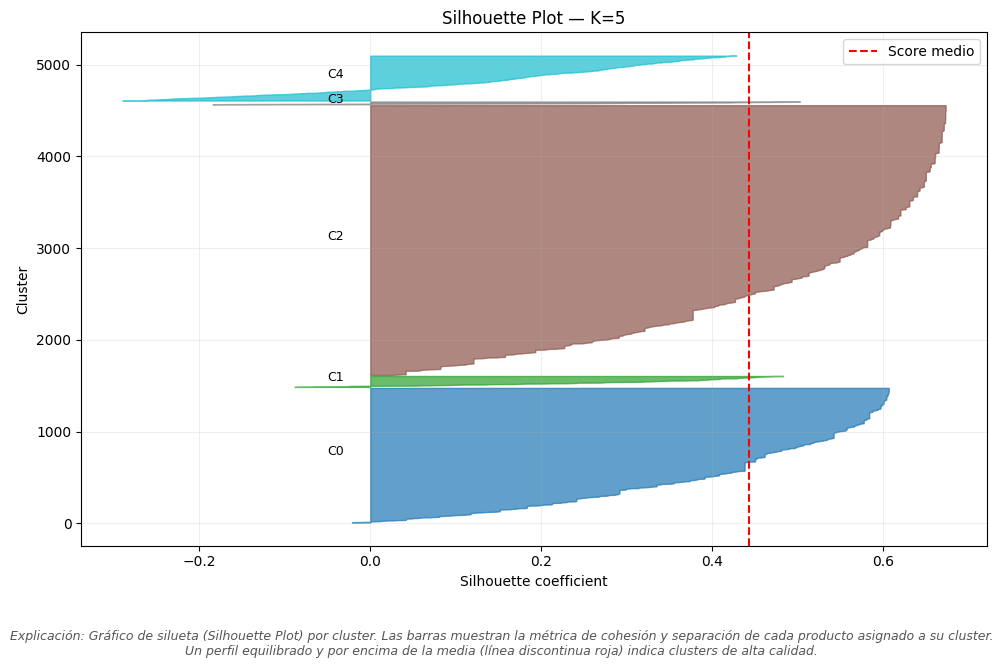

In [50]:
# ── CELDA 9: Silhouette plot por cluster ──────────────────────────────────────
"""
El Silhouette plot muestra la calidad de asignación de cada producto
a su cluster. Barras anchas y simétricas = clusters bien definidos.
"""
silhouette_vals = silhouette_samples(X_scaled, df_features["cluster"])
fig, ax = plt.subplots(figsize=(10, 7))

y_lower = 10
for c in range(K_FINAL):
    vals_c = np.sort(silhouette_vals[df_features["cluster"] == c])
    size_c = len(vals_c)
    y_upper = y_lower + size_c

    color = colores[c]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals_c,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + size_c / 2, f"C{c}", fontsize=9)
    y_lower = y_upper + 10

ax.axvline(x=silhouette_score(X_scaled, df_features["cluster"]),
           color="red", linestyle="--", label="Score medio")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Cluster")
ax.set_title(f"Silhouette Plot — K={K_FINAL}")
ax.legend()
ax.grid(True, alpha=0.2)

caption = "Explicación: Gráfico de silueta (Silhouette Plot) por cluster. Las barras muestran la métrica de cohesión y separación de cada producto asignado a su cluster. Un perfil equilibrado y por encima de la media (línea discontinua roja) indica clusters de alta calidad."
plt.figtext(0.5, 0.01, caption, wrap=True, horizontalalignment='center', fontsize=9, style='italic', color='#555555')
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.savefig(IMG_DIR / "silhouette_plot.png", dpi=150, bbox_inches="tight")
plt.show()

In [51]:
# ── CELDA 10: Guardar resultados ──────────────────────────────────────────────
OUTPUT = Path("../data/clustering/kmeans_resultados.parquet")
OUTPUT.parent.mkdir(parents=True, exist_ok=True)

cols_guardar = ["referencia", "titulo", "categoria", "subcategoria",
                "marca_propia", "es_marca_propia", "cluster"] + FEATURE_COLS

df_features[cols_guardar].to_parquet(OUTPUT, index=False)
print(f"✅ Resultados guardados: {OUTPUT}")
print(f"   {len(df_features):,} productos con cluster asignado")

✅ Resultados guardados: ..\data\clustering\kmeans_resultados.parquet
   5,049 productos con cluster asignado
